# Lección 4 – Clusterización con K-Means, DBSCAN y Agrupamiento Jerárquico

En esta lección aplicaremos algoritmos de clusterización sobre los datos de clientes ya preprocesados en la Lección 3.
Utilizaremos K-Means, DBSCAN y agrupamiento jerárquico, y analizaremos visualmente los clústeres.


## 1. Preparación: carga y preprocesamiento

Cargamos nuevamente los datos y reutilizamos el mismo pipeline de preprocesamiento definido en la Lección 3 para obtener la matriz `X_train_prep`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Cargar datos
train = pd.read_csv('Train.csv')

# Definir columnas numéricas y categóricas
numeric_features = []
categorical_features = []

for col, dtype in train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_prep = preprocessor.fit_transform(train)
X_for_clust = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep

X_for_clust.shape

(8068, 33)

## 2. Reducción a 2 dimensiones para visualización (PCA)

Reducimos los datos preprocesados a 2 dimensiones con PCA para poder graficar los clústeres en un plano 2D.


In [2]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_for_clust)

X_pca_2[:5]

array([[-2.13083365, -0.75359718],
       [ 0.20622766, -0.36053353],
       [ 1.84301363,  0.23787553],
       [ 2.0493703 , -0.31981119],
       [-0.32257446, -1.43155727]])

## 3. K-Means: elección de k (método del codo)

Aplicamos K-Means para distintos valores de `k` y calculamos la inercia para usar el método del codo y orientar la elección del número de clústeres.


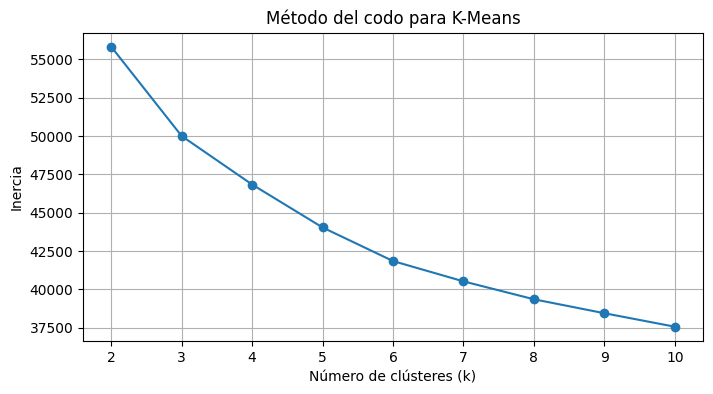

[55833.59489238804,
 50004.73788366191,
 46839.090208347116,
 44035.66020352755,
 41843.03813982998,
 40516.943269936644,
 39347.10556420182,
 38437.36954315409,
 37556.46488120106]

In [3]:
inertias = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_for_clust)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para K-Means')
plt.grid(True)
plt.show()

inertias

## 4. K-Means: coeficiente de silueta

Calculamos el coeficiente de silueta para distintos valores de `k` para evaluar la separación de los clústeres.


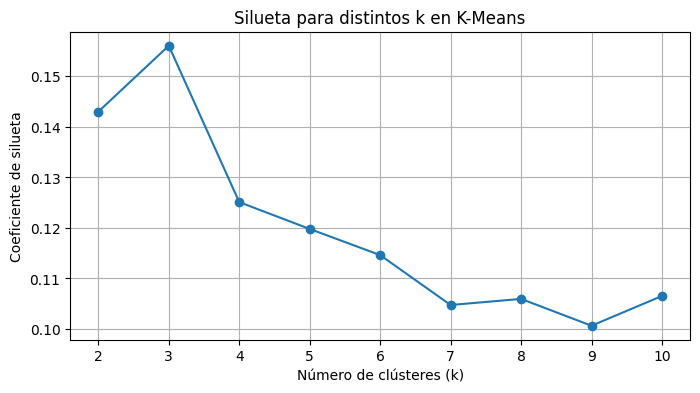

[0.14301297082438846,
 0.15606540039010403,
 0.1251120495805612,
 0.11979886434050971,
 0.11462400545205242,
 0.10474688481421254,
 0.10595628121618293,
 0.10064596769774481,
 0.10653350008937386]

In [4]:
silhouettes = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_for_clust)
    score = silhouette_score(X_for_clust, labels)
    silhouettes.append(score)

plt.figure(figsize=(8,4))
plt.plot(ks, silhouettes, marker='o')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Coeficiente de silueta')
plt.title('Silueta para distintos k en K-Means')
plt.grid(True)
plt.show()

silhouettes

## 5. K-Means: ajuste final y visualización en 2D

Elegimos un valor de `k` (por ejemplo, el que tenga buena silueta y un “codo” razonable) y visualizamos los clústeres sobre las componentes principales de PCA.


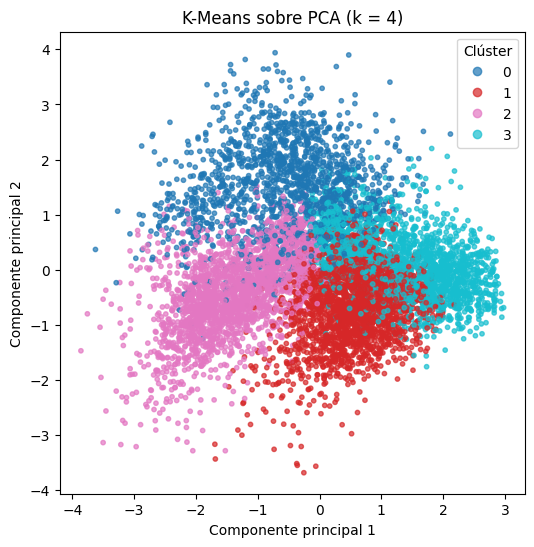

0.1251120495805612

In [5]:
# Elegir k (ajustar manualmente según los gráficos)
best_k = 4

kmeans_final = KMeans(n_clusters=best_k, random_state=42)
labels_kmeans = kmeans_final.fit_predict(X_for_clust)

plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('K-Means sobre PCA (k = %d)' % best_k)
plt.legend(*scatter.legend_elements(), title='Clúster')
plt.show()

silhouette_kmeans = silhouette_score(X_for_clust, labels_kmeans)
silhouette_kmeans

## 6. DBSCAN: ajuste de parámetros y clusterización

Aplicamos DBSCAN y exploramos el efecto de distintos parámetros `eps` y `min_samples`.
Los puntos etiquetados como `-1` son considerados ruido (outliers).


In [6]:
eps = 0.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_for_clust)

unique_labels = np.unique(labels_dbscan)
unique_labels, np.bincount(labels_dbscan + 1)  # desplazamos +1 para contar -1

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
        50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
        67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]),
 array([7282,    5,   13,   31,   37,   79,   21,   22,    8,    9,    8,
           7,    5,    5,    7,   20,    8,    7,    7,   34,    7,   10,
           6,   13,    9,   37,   12,   11,    8,    8,    8,    8,    6,
          14,    8,    6,    5,    7,   16,    6,    9,    5,   13,    8,
          13,    8,    5,    8,   11,   10,    5,    7,    6,    5,    5,
           5,    5,    6,    9,    5,    6,    5,    7,    5,    8,    5,
           5,    5,    5,    5,    2,    7,    5,    5,    5,    5,    5,
           5,    5]))

### 6.1 Visualización de DBSCAN en PCA 2D

Graficamos los clústeres de DBSCAN sobre las dos componentes principales de PCA.


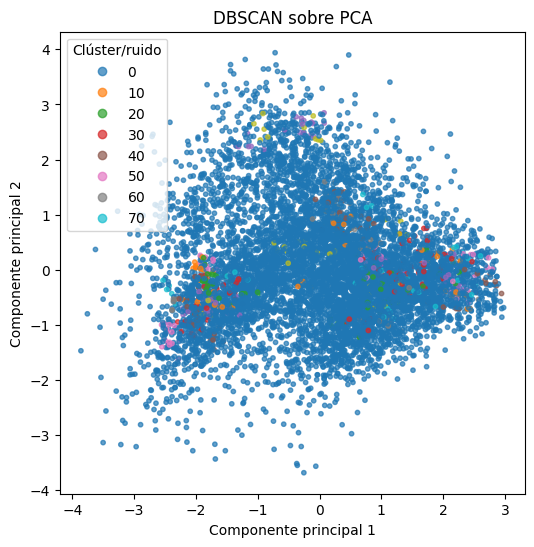

0.41883037404380236

In [7]:
plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('DBSCAN sobre PCA')
plt.legend(*scatter.legend_elements(), title='Clúster/ruido')
plt.show()

# Silueta solo si hay al menos 2 clústeres válidos (excluyendo -1)
labels_unique = set(labels_dbscan)
labels_unique.discard(-1)
if len(labels_unique) > 1:
    mask = labels_dbscan != -1
    silhouette_dbscan = silhouette_score(X_for_clust[mask], labels_dbscan[mask])
    silhouette_dbscan
else:
    silhouette_dbscan = None
silhouette_dbscan

## 7. Agrupamiento jerárquico

Aplicamos agrupamiento jerárquico aglomerativo para un número elegido de clústeres y visualizamos el resultado en 2D.


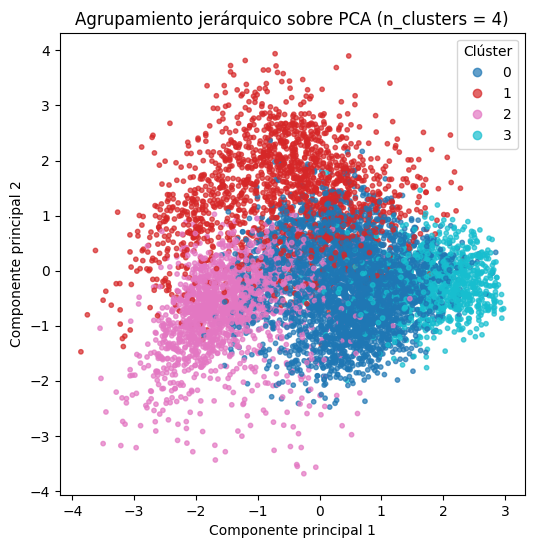

0.10271159603200981

In [8]:
n_clusters_hier = 4

agg = AgglomerativeClustering(n_clusters=n_clusters_hier)
labels_agg = agg.fit_predict(X_for_clust)

plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Agrupamiento jerárquico sobre PCA (n_clusters = %d)' % n_clusters_hier)
plt.legend(*scatter.legend_elements(), title='Clúster')
plt.show()

silhouette_agg = silhouette_score(X_for_clust, labels_agg)
silhouette_agg

## 8. Resumen de resultados de clusterización

En esta lección hemos:

1. Aplicado K-Means con distintas cantidades de clústeres y usado el método del codo y el coeficiente de silueta para elegir un `k` adecuado.
2. Aplicado DBSCAN para detectar clústeres basados en densidad y ruido.
3. Aplicado agrupamiento jerárquico para explorar la estructura de clústeres a un número fijo.
4. Visualizado todos los resultados sobre la proyección PCA en 2D.

En la siguiente lección compararemos en detalle las segmentaciones, evaluaremos su consistencia e iniciaremos la redacción del informe final.
